In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

from matplotlib.ticker import FormatStrFormatter
sys.path.append(os.path.expanduser('~/git/desi-lrg-selection'))
import plotting_scripts as lrg_plot

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
nmad = lambda x: 1.4826 * np.median(np.abs(x-np.median(x)))

In [4]:
cat = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/data/ls_dr9.0_photoz/misc/lss_daily_y1_lrg_full_20221031.fits'))
pz = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/data/ls_dr9.0_photoz/misc/lss_daily_y1_lrg_full_20221031-pz_new.fits'))
cat['Z_PHOT_MEDIAN'] = pz['Z_PHOT_MEDIAN']
print(len(cat))

cat['EFFTIME_LRG'] = 12.15 * cat['TSNR2_LRG']

mask = cat['COADD_FIBERSTATUS']==0
cat = cat[mask]
print(len(cat), len(np.unique(cat['TARGETID'])))

mask = cat['EFFTIME_LRG']>800
print(np.sum(mask)/len(mask))
cat = cat[mask]
print(len(cat), len(np.unique(cat['TARGETID'])))

# Redshift quality cut
cat['q'] = cat['ZWARN']==0
cat['q'] &= cat['Z']<1.45
cat['q'] &= cat['DELTACHI2']>15
mask = cat['q'].copy()
print('Redshift quality cuts:', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove objects classified as STARs
mask = (cat['SPECTYPE']!='STAR') & (cat['Z']>=0.0003)
print('Remove objects classified as STARs:', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

bad_fibers = np.loadtxt('/global/u2/r/rongpu/notebooks/lrg_xcorr/data/bad_fibers_daily_20221101.txt', dtype=int)
print(len(bad_fibers))
mask_bad = np.in1d(cat['FIBER'], bad_fibers)
print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
cat = cat[~mask_bad]

2395952
2363936
2355983
62
Bad fibers 2337891 18092 0.007679172557696724


In [5]:
mask_north = cat['PHOTSYS']=='N'
mask_south = cat['PHOTSYS']=='S'
print(np.sum(mask_north), np.sum(mask_south))

387973 1949918


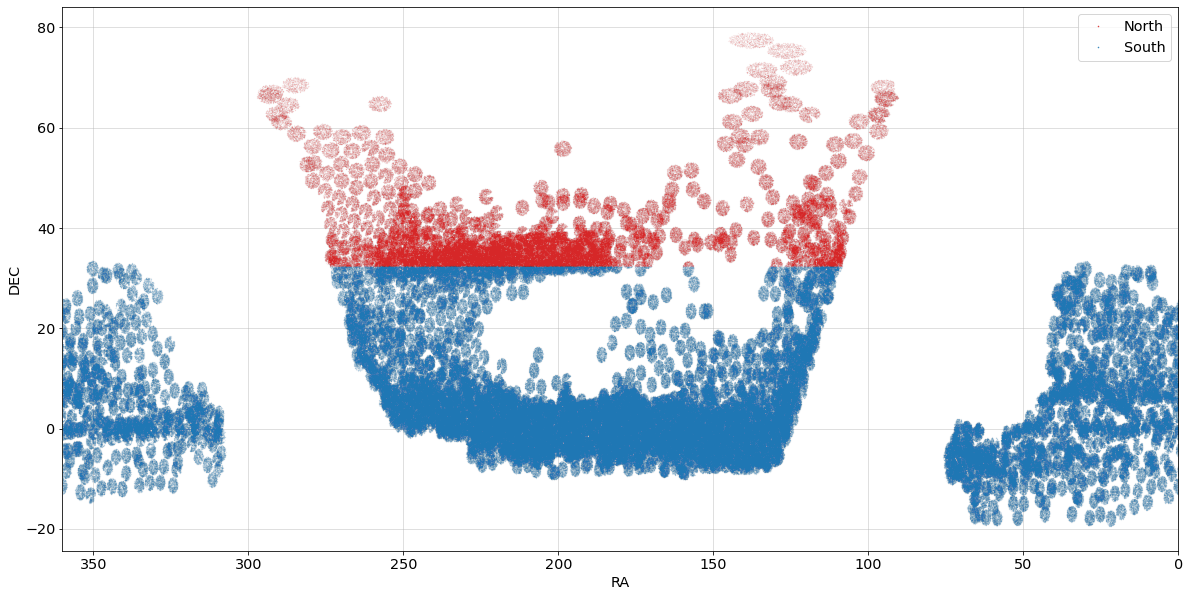

In [6]:
plt.figure(figsize=(20, 10))
plt.plot(cat['RA'][mask_north], cat['DEC'][mask_north], 'C3.', ms=.05, label='North')
plt.plot(cat['RA'][mask_south], cat['DEC'][mask_south], 'C0.', ms=.05, label='South')
plt.xlabel('RA')
plt.ylabel('DEC')
plt.legend(loc='upper right', markerscale=20)
plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.xlim(360, 0)
plt.show()

In [7]:
# numbers from another notebook
area_tot = 10109.0
n_mask_tot = 6159414
density_tot = n_mask_tot/area_tot
print(density_tot)

area_south = np.sum(mask_south)/n_mask_tot * area_tot
print(area_south)

area_north = np.sum(mask_north)/n_mask_tot * area_tot
print(area_north)

area = area_south + area_north
print(area)

609.3000296765259
3200.2591580952344
636.7519794902568
3837.0111375854913


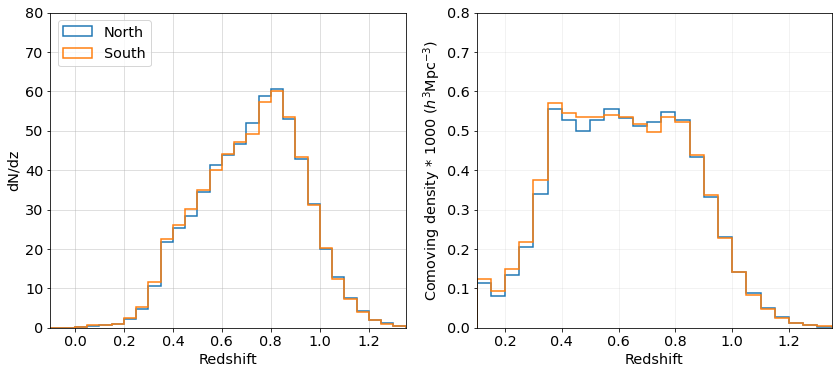

In [8]:
bins = np.arange(-0.1, 1.45, 0.05)
bin_centers = (bins[1:]+bins[:-1])/2

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
axes[0].hist(cat['Z'][mask_north], weights=np.ones(int(np.sum(mask_north)))/area_north,
             bins=bins, lw=1.5, histtype='step', label='North', color='C0')
axes[0].hist(cat['Z'][mask_south], weights=np.ones(int(np.sum(mask_south)))/area_south,
             bins=bins, lw=1.5, histtype='step', label='South', color='C1')
# axes[0].hist(bin_centers, counts_final/area, yerr=frac_err*counts_final/area, fmt='o', ms=5, color='C0', capsize=3, capthick=1, label='New Baseline')
axes[0].legend(loc='upper left')
axes[0].set_xlabel('Redshift')
axes[0].set_ylabel('dN/dz')
axes[0].set_xlim(-0.1, 1.35)
axes[0].set_ylim(0, 80)
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axes[0].grid(alpha=0.5)
# axes[0].set_ylim(top=30)
axes[1] = lrg_plot.plot_comoving_density(cat['Z'][mask_north], area=area_north, zmin=0.1, zmax=bins.max(), dz=0.05, axis=[0.1, 1.35, 0, 0.8], xlabel='Redshift', show=False, lw=1.5, color='C0', errorbar=False)
axes[1] = lrg_plot.plot_comoving_density(cat['Z'][mask_south], area=area_south, zmin=0.1, zmax=bins.max(), dz=0.05, axis=[0.1, 1.35, 0, 0.8], xlabel='Redshift', show=False, lw=1.5, color='C1', errorbar=False)
# plt.legend(loc='lower left')
plt.show()

In [9]:
pz_cuts_south = [0.400, 0.540, 0.713, 0.860, 1.020]
pz_cuts_north = [0.400, 0.545, 0.719, 0.851, 1.024]

print('South:\n')
mask_all = mask_south & (cat['Z_PHOT_MEDIAN']>pz_cuts_south[0]) & (cat['Z_PHOT_MEDIAN']<pz_cuts_south[-1])
for index in range(len(pz_cuts_south)-1):
    pz_min, pz_max = pz_cuts_south[index], pz_cuts_south[index+1]
    mask = mask_south & (cat['Z_PHOT_MEDIAN']>pz_min) & (cat['Z_PHOT_MEDIAN']<pz_max)
    print('bin {} fraction: {:.4f}'.format(index+1, np.sum(mask)/np.sum(mask_all)))
    # print(np.percentile(cat['Z'][mask], [2, 16, 50, 84, 98]))
    print('mean redshift: {:.3f}'.format(np.median(cat['Z'][mask])))
    # print('1-sigma width: {:.3f};   2-sigma width: {:.3f}'.format(np.percentile(cat['Z'][mask], 84)-np.percentile(cat['Z'][mask], 16),
    #     np.percentile(cat['Z'][mask], 98)-np.percentile(cat['Z'][mask], 2)))
    print('nmad: {:.3f}'.format(nmad(cat['Z'][mask])))

print()

print('North:\n')
mask_all = mask_north & (cat['Z_PHOT_MEDIAN']>pz_cuts_north[0]) & (cat['Z_PHOT_MEDIAN']<pz_cuts_north[-1])
for index in range(len(pz_cuts_north)-1):
    pz_min, pz_max = pz_cuts_north[index], pz_cuts_north[index+1]
    mask = mask_north & (cat['Z_PHOT_MEDIAN']>pz_min) & (cat['Z_PHOT_MEDIAN']<pz_max)
    print('bin {} fraction: {:.4f}'.format(index+1, np.sum(mask)/np.sum(mask_all)))
    # print(np.percentile(cat['Z'][mask], [2, 16, 50, 84, 98]))
    print('mean redshift: {:.3f}'.format(np.median(cat['Z'][mask])))
    # print('1-sigma width: {:.3f};   2-sigma width: {:.3f}'.format(np.percentile(cat['Z'][mask], 84)-np.percentile(cat['Z'][mask], 16),
    #     np.percentile(cat['Z'][mask], 98)-np.percentile(cat['Z'][mask], 2)))
    print('nmad: {:.3f}'.format(nmad(cat['Z'][mask])))

South:

bin 1 fraction: 0.1538
mean redshift: 0.473
nmad: 0.059
bin 2 fraction: 0.2722
mean redshift: 0.628
nmad: 0.068
bin 3 fraction: 0.2990
mean redshift: 0.788
nmad: 0.066
bin 4 fraction: 0.2750
mean redshift: 0.920
nmad: 0.084

North:

bin 1 fraction: 0.1519
mean redshift: 0.475
nmad: 0.061
bin 2 fraction: 0.2748
mean redshift: 0.630
nmad: 0.069
bin 3 fraction: 0.2971
mean redshift: 0.789
nmad: 0.067
bin 4 fraction: 0.2762
mean redshift: 0.919
nmad: 0.086


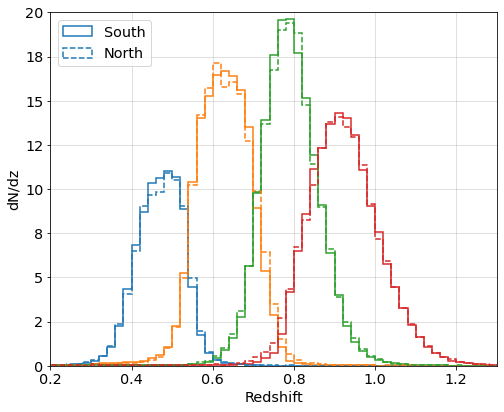

In [10]:
bins = np.arange(-0.1, 1.45, 0.02)
bin_centers = (bins[1:]+bins[:-1])/2

fig, ax = plt.subplots(figsize=(8, 6.5))

for index in range(len(pz_cuts_south)-1):
    pz_min, pz_max = pz_cuts_south[index], pz_cuts_south[index+1]
    if index==0:
        label = 'South'
    else:
        label = None
    mask = mask_south & (cat['Z_PHOT_MEDIAN']>pz_min) & (cat['Z_PHOT_MEDIAN']<pz_max)
    ax.hist(cat['Z'][mask], weights=np.ones(int(np.sum(mask)))/area_south,
                 bins=bins, lw=1.5, histtype='step', label=label, color='C'+str(index))
for index in range(len(pz_cuts_north)-1):
    pz_min, pz_max = pz_cuts_north[index], pz_cuts_north[index+1]
    if index==0:
        label = 'North'
    else:
        label = None
    mask = mask_north & (cat['Z_PHOT_MEDIAN']>pz_min) & (cat['Z_PHOT_MEDIAN']<pz_max)
    ax.hist(cat['Z'][mask], weights=np.ones(int(np.sum(mask)))/area_north,
                 bins=bins, lw=1.5, histtype='step', label=label, color='C'+str(index), ls='--')

ax.legend(loc='upper left')
ax.set_xlabel('Redshift')
ax.set_ylabel('dN/dz')
ax.set_xlim(0.2, 1.3)
ax.set_ylim(0, 20)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax.grid(alpha=0.5)
plt.show()

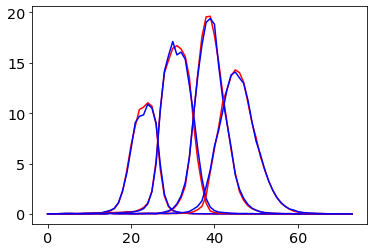

In [11]:
bins = np.round(np.arange(0., 1.5, 0.02), 2)

t = Table()
t['zmin'] = bins[:-1]
t['zmax'] = bins[1:]

for index in range(len(pz_cuts_north)-1):
    pz_min, pz_max = pz_cuts_north[index], pz_cuts_north[index+1]
    mask = mask_north & (cat['Z_PHOT_MEDIAN']>pz_min) & (cat['Z_PHOT_MEDIAN']<pz_max)
    counts = np.histogram(cat['Z'][mask], bins=bins)[0]
    surf_density = counts/area_north
    t['bin_{}_north'.format(index+1)] = surf_density
    t['bin_{}_north'.format(index+1)].format = '%.1f'

for index in range(len(pz_cuts_south)-1):
    pz_min, pz_max = pz_cuts_south[index], pz_cuts_south[index+1]
    mask = mask_south & (cat['Z_PHOT_MEDIAN']>pz_min) & (cat['Z_PHOT_MEDIAN']<pz_max)
    counts = np.histogram(cat['Z'][mask], bins=bins)[0]
    surf_density = counts/area_south
    t['bin_{}_south'.format(index+1)] = surf_density
    t['bin_{}_south'.format(index+1)].format = '%.1f'
    
# t.write('data/main_lrg_pz_dndz_v1_dz_002.txt', format='ascii.commented_header', overwrite=True)

for index in range(len(pz_cuts_north)-1):
    plt.plot(t['bin_{}_south'.format(index+1)], color='r')
    plt.plot(t['bin_{}_north'.format(index+1)], color='b')
plt.show()

Smaller bins

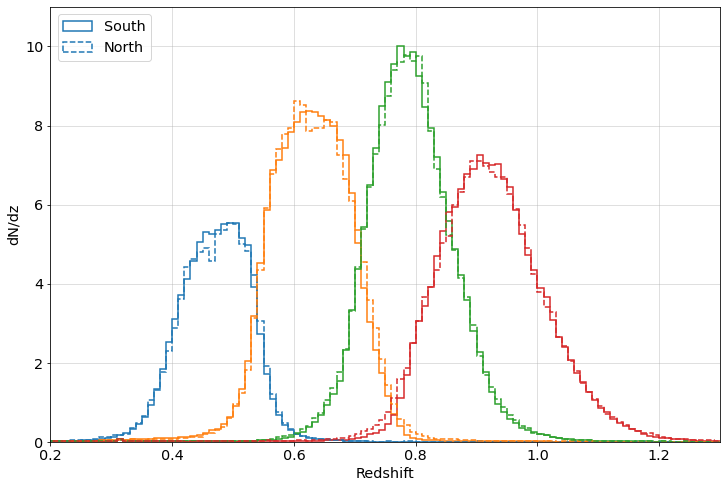

In [12]:
bins = np.arange(-0.1, 1.45, 0.01)
bin_centers = (bins[1:]+bins[:-1])/2

fig, ax = plt.subplots(figsize=(12, 8))

for index in range(len(pz_cuts_south)-1):
    pz_min, pz_max = pz_cuts_south[index], pz_cuts_south[index+1]
    if index==0:
        label = 'South'
    else:
        label = None
    mask = mask_south & (cat['Z_PHOT_MEDIAN']>pz_min) & (cat['Z_PHOT_MEDIAN']<pz_max)
    ax.hist(cat['Z'][mask], weights=np.ones(int(np.sum(mask)))/area_south,
                 bins=bins, lw=1.5, histtype='step', label=label, color='C'+str(index))
for index in range(len(pz_cuts_north)-1):
    pz_min, pz_max = pz_cuts_north[index], pz_cuts_north[index+1]
    if index==0:
        label = 'North'
    else:
        label = None
    mask = mask_north & (cat['Z_PHOT_MEDIAN']>pz_min) & (cat['Z_PHOT_MEDIAN']<pz_max)
    ax.hist(cat['Z'][mask], weights=np.ones(int(np.sum(mask)))/area_north,
                 bins=bins, lw=1.5, histtype='step', label=label, color='C'+str(index), ls='--')

ax.legend(loc='upper left')
ax.set_xlabel('Redshift')
ax.set_ylabel('dN/dz')
ax.set_xlim(0.2, 1.3)
ax.set_ylim(0, 11)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax.grid(alpha=0.5)
plt.show()

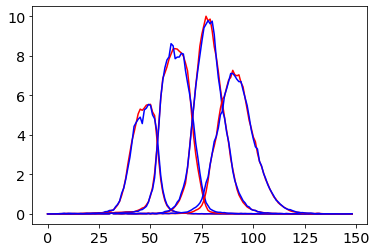

In [13]:
bins = np.round(np.arange(0., 1.5, 0.01), 2)

t = Table()
t['zmin'] = bins[:-1]
t['zmax'] = bins[1:]

for index in range(len(pz_cuts_north)-1):
    pz_min, pz_max = pz_cuts_north[index], pz_cuts_north[index+1]
    mask = mask_north & (cat['Z_PHOT_MEDIAN']>pz_min) & (cat['Z_PHOT_MEDIAN']<pz_max)
    counts = np.histogram(cat['Z'][mask], bins=bins)[0]
    surf_density = counts/area_north
    t['bin_{}_north'.format(index+1)] = surf_density
    t['bin_{}_north'.format(index+1)].format = '%.1f'

for index in range(len(pz_cuts_south)-1):
    pz_min, pz_max = pz_cuts_south[index], pz_cuts_south[index+1]
    mask = mask_south & (cat['Z_PHOT_MEDIAN']>pz_min) & (cat['Z_PHOT_MEDIAN']<pz_max)
    counts = np.histogram(cat['Z'][mask], bins=bins)[0]
    surf_density = counts/area_south
    t['bin_{}_south'.format(index+1)] = surf_density
    t['bin_{}_south'.format(index+1)].format = '%.1f'
    
# t.write('data/main_lrg_pz_dndz_v1_dz_001.txt', format='ascii.commented_header', overwrite=True)

for index in range(len(pz_cuts_north)-1):
    plt.plot(t['bin_{}_south'.format(index+1)], color='r')
    plt.plot(t['bin_{}_north'.format(index+1)], color='b')
plt.show()